In [13]:
from astroquery.cadc import Cadc
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

cadc = Cadc()

# Координаты Ауриги/Калифорнии из вашего лога
center_coords = SkyCoord(ra=65.0, dec=38.08333333, unit=(u.deg, u.deg), frame='icrs')

print("Забрасываем сеть в радиусе 1.5 градусов...")
results = cadc.query_region(center_coords, radius=1.5 * u.deg, collection='JCMT')

if len(results) == 0:
    print("[-] JCMT вообще никогда не смотрел в эту точку. Координаты точно верные?")
else:
    print(f"[+] Бинго! Найдено сырых и готовых записей JCMT: {len(results)}\n")
    
    # 1. Смотрим, какие проекты тут наследили
    # Игнорируем записи без proposal_id
    valid_proposals = [pid for pid in results['proposal_id'] if pid]
    if valid_proposals:
        unique_proposals = np.unique(valid_proposals)
        print("Коды проектов (proposal_id), которые снимали эту область:")
        for pid in unique_proposals:
            print(f" - {pid}")
    
    print("\n-------------------\n")
    
    # 2. Смотрим, как они обзывали этот объект
    valid_targets = [t for t in results['target_name'] if t]
    if valid_targets:
        unique_targets = np.unique(valid_targets)
        print("Как наблюдатели называли этот объект (target_name):")
        for target in unique_targets:
            print(f" - {target}")

Забрасываем сеть в радиусе 1.5 градусов...
[+] Бинго! Найдено сырых и готовых записей JCMT: 1738

Коды проектов (proposal_id), которые снимали эту область:
 - CAL
 - E23AK001
 - INTERF
 - JCMT-LR
 - JCMTCAL
 - M03AC03
 - M04BC03
 - M04BC09
 - M04BC20
 - M04BC28
 - M04BN07
 - M04BU35
 - M05BC18
 - M05BU59
 - M06BEC25
 - M06BEC28
 - M07BEC28
 - M09AC10
 - M12BH03E
 - M12BU16
 - M15BI061
 - M16AL003
 - M16AN002
 - M20AP008
 - M20BP060
 - M22AP010
 - M22BP035
 - M22BV001
 - M96BC24
 - MJLSG37
 - R19BP002
 - S04AN11
 - TEST
 - m03au46
 - m97bu66
 - m99au42

-------------------

Как наблюдатели называли этот объект (target_name):
 - 05189-25
 - 09320+613
 - 3C 111.0
 - 3C111
 - 3C446
 - 3C454.3
 - 3c111
 - ARP55
 - AUR_Central-E
 - AUR_Central-N
 - AUR_Central-W
 - CRL618
 - CTA102
 - DF3023
 - G160.8-09.4A1
 - G160.8-09.4A2
 - G161.3-09.3A1
 - G161.56-9.29
 - G162.4-08.7A1
 - G162.4-08.7A2
 - G163.32-8.41
 - IRAS05189-25
 - J1048+4637
 - L1478 F8-C4
 - L1478 F8-C4 cen
 - L1478 F8-C4 nw
 - L

 BISTRO-1 M16AL004 BISTRO-2 (M17BL011) и BISTRO-3 (M19AL005).

(Proposal ID) первой фазы консорциума BISTRO (B-fields In STar-forming Region Observations) на телескопе JCMT

In [23]:
import astropy.units as u
from astroquery.cadc import Cadc
import numpy as np

cadc = Cadc()
print("Инициализация глобального поиска по Ауриге (радиус 1.5 градуса)...")

# 1. Поиск по имени (SIMBAD автоматически разрешит координаты)
results = cadc.query_region('Auriga', radius=1.5 * u.deg, collection='JCMT')

# 2. Жесткий фильтр: оставляем ТОЛЬКО инструмент SCUBA-2
scuba_mask = ['SCUBA-2' in str(inst).upper() for inst in results['instrument_name']]
scuba_data = results[scuba_mask]

print(f"\nВсего найдено файлов SCUBA-2: {len(scuba_data)}")

if len(scuba_data) > 0:
    # 3. Изолируем только те файлы, где прописаны параметры Стокса (Q или U)
    pol_mask = ['Q' in str(state).upper() for state in scuba_data['polarization_states']]
    pol_data = scuba_data[pol_mask]
    
    print(f"Из них файлов с поляризацией (I, Q, U): {len(pol_data)}")
    
    if len(pol_data) > 0:
        print("\n[+] Метаданные поляризационных файлов:")
        # Выводим самое важное: ID файла, проект, уровень обработки и Стоксы
        print(pol_data['target_name', 'proposal_id', 'calibrationLevel', 'polarization_states', 'productID'])
    else:
        print("\n[-] SCUBA-2 данные найдены, но параметров Q и U в них нет (только I).")
        print("\nДоступные таргеты в этих данных:")
        print(np.unique(scuba_data['target_name']))
else:
    print("Данных SCUBA-2 в этом регионе не найдено.")

Инициализация глобального поиска по Ауриге (радиус 1.5 градуса)...

Всего найдено файлов SCUBA-2: 639
Из них файлов с поляризацией (I, Q, U): 0

[-] SCUBA-2 данные найдены, но параметров Q и U в них нет (только I).

Доступные таргеты в этих данных:
      target_name      
-----------------------
                       
                  3C111
          AUR_Central-E
          AUR_Central-N
          AUR_Central-W
                 CRL618
          G160.8-09.4A1
          G160.8-09.4A2
          G161.3-09.3A1
           G161.56-9.29
                    ...
SCUBA-2 850um tile 1255
SCUBA-2 850um tile 1261
SCUBA-2 850um tile 1262
SCUBA-2 850um tile 1263
SCUBA-2 850um tile 1266
SCUBA-2 850um tile 1272
SCUBA-2 850um tile 1604
SCUBA-2 850um tile 1606
SCUBA-2 850um tile 1607
SCUBA-2 850um tile 1617
Length = 24 rows


In [43]:
import requests
from astropy.io import fits
import os

# Берем первую строку из вашей таблицы (scuba_data или pol_data)
row = scuba_data[0] # Если pol_data недоступна, замените на scuba_data[0]

collection = row['collection']
product_id = row['productID']

# Собираем прямую ссылку ВРУЧНУЮ (в обход бага astroquery)
manual_url = f"https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/data/pub/{collection}/{product_id}"

test_filename = f"test_auriga_{product_id}.fits"

print(f"Пробиваемся к файлу напрямую: {manual_url}")
print(f"Скачиваем {test_filename}...")

# Качаем файл
response = requests.get(manual_url, stream=True)

if response.status_code == 200:
    with open(test_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            
    print("\n[OK] Шах и мат, CADC. Файл скачан.")
    print("\n--- Вскрытие FITS файла ---")
    
    # Инспектируем слои, чтобы найти VARIANCE
    with fits.open(test_filename) as hdul:
        hdul.info()
else:
    print(f"[-] Сервер CADC отклонил запрос: HTTP {response.status_code}")
    print("Возможно, этот конкретный файл является проприетарным или ссылка формируется нестандартно.")

Пробиваемся к файлу напрямую: https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/data/pub/JCMT/reduced-850um
Скачиваем test_auriga_reduced-850um.fits...
[-] Сервер CADC отклонил запрос: HTTP 401
Возможно, этот конкретный файл является проприетарным или ссылка формируется нестандартно.


In [55]:
from astropy.io import fits
import matplotlib.pyplot as plt

TypeError: Image data of dtype object cannot be converted to float

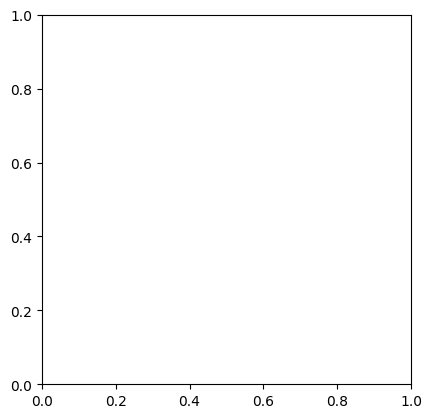

In [57]:
plt.imshow(fits.open("/Users/ildana/Downloads/JCMT/jcmts850um_extent-cat001263_pub_000.fits")[0].data